![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

## Analisis del total por Temporada

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

El primer filtro aplicado en la celda 1.1 nos muestra el promedio de usarios (Ocasionales y registrados) por temporada (Invierno, primavera, Verano y Otoño respectivamente).

Donde los valores parecen indicar un mayor registro de usuarios en temporada de Verano y un menor Registro en epoca de invierno para el total de Bicicletas alquiladas en cada temporada, este efecto se ve al comparar las temporadas de Primavera y Otoño, lo que indica que hay un mayor alquiler de bicicletas por parte de los usuarios en temporadas calidad que en las temporadas frias, mostrando un crecimiento progresivo en demanda, desde el invierno hacia el verano.

## Analisis del total por Hora

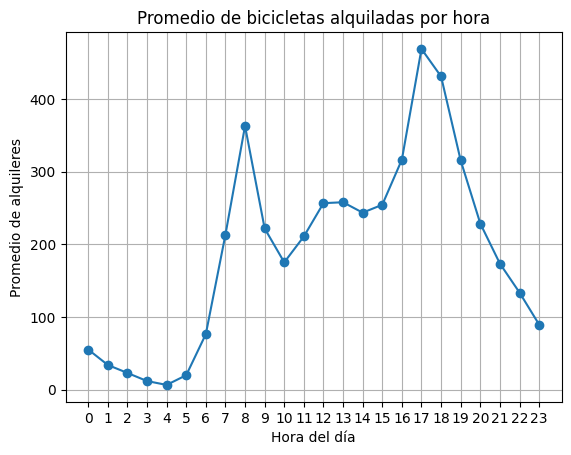

In [5]:
# Celda 1.2
plt.figure()
bikes.groupby('hour').total.mean().plot(
    kind='line',
    marker='o'
)

plt.title('Promedio de bicicletas alquiladas por hora')
plt.xlabel('Hora del día')
plt.ylabel('Promedio de alquileres')

plt.xticks(range(0, 24))  # asegura que se muestren todas las horas
plt.grid(True)

plt.show()


El primer filtro aplicado en la celda 1.2 nos muestra el promedio de usarios (Ocasionales y registrados) por horas del día, en un formato de 0-23h.

Mediante  un diagrama de puntos es posible visualizar el comportamiento de demanda de bicicletas por hora del día , la grafica indica una baja demanda en horas de la madrugrada entre las 0 y 5:00 h , siendo las 4:00 h el punto de menor demanda de biciletas en el día.


A partir de las 6:00 se observa un incremento significativo alcanzndo el primer pico entre las 7 y 8:00 h , sugiriendo un comportamiento asociado al inicio de jornadas academicas y laborales

seguido a esto, la demanda disminuye ligreramente durante la mitad del día entre las 9 y 15:00 h asociado a actividades recreativas o desplazamientos intermedios 

Finalmente se presenta un segundo pico  alas 17:00 h , siendo las 17:00 horas la franja horaria con un pico en la demanda de bisicletas por parte de los usuarios, apartir de este punto, la demanda decrece progresivamente durante la llegada de la noche.

el comportamiento de la demanda presenta un patrón bimodal, con dos picos principales en la mañana y en la tarde, lo que evidencia que la demanda de bicicletas está fuertemente relacionada con los hábitos de movilidad diaria de los usuarios.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

In [6]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

<Axes: xlabel='hour'>

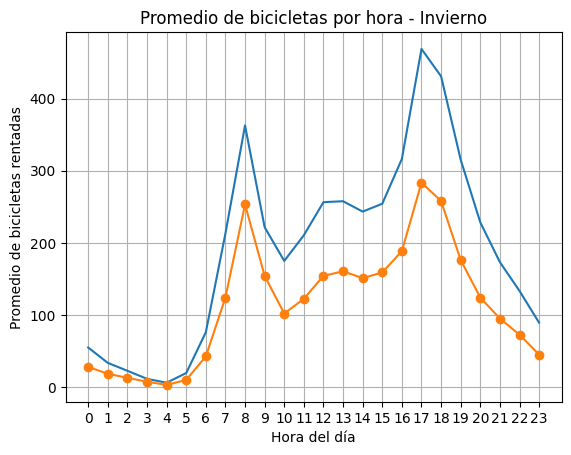

In [7]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season'] == 1].groupby('hour')['total'].mean().plot(
    kind='line',
    marker='o',
    title='Promedio de bicicletas por hora - Invierno'
)

plt.xticks(range(0,24))
plt.grid(True)
plt.xlabel('Hora del día')
plt.ylabel('Promedio de bicicletas rentadas')
plt.show()

El comportamiento grafico de la demanda promedio de biciletas por hora durante la temporada de invierno tiene una siimilitud en forma a la grafica general, pero en proporciones diferentes, lo cual es coherente con la tendencia de demanda por estaciones observada anteriormente

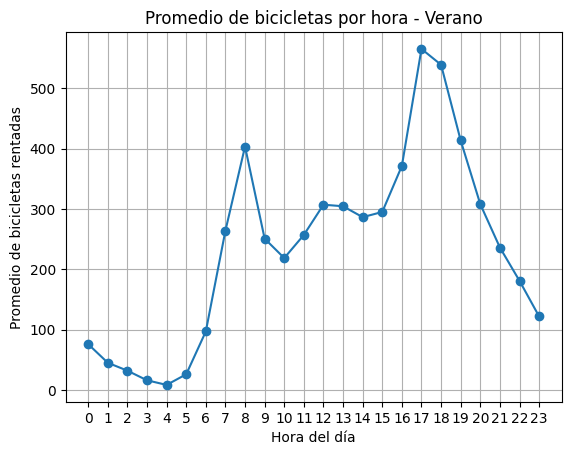

In [8]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season'] == 3].groupby('hour')['total'].mean().plot(
    kind='line',
    marker='o',
    title='Promedio de bicicletas por hora - Verano'
)
plt.xticks(range(0,24))
plt.grid(True)
plt.xlabel('Hora del día')
plt.ylabel('Promedio de bicicletas rentadas')
plt.show()

Caso simila ocurre con el comportamiento grafico de la demanda promedio de biciletas por hora durante la temporada de Verano , esta vez, mostrando una escala más alta sobre la tendencia de demanda de biciletas por hora respecto a la grafica de horas en temporada de invierno, encontrando incluso una mayor demanda en horas pico , lo que refuerza la premisa respecto a la preferencia de los usuarios sobre el uso de bicicletas durante la temporada de Verano.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [9]:
# Celda 3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV

# CODIFICACION VARIABLE SEASON

bikes_encoded = pd.get_dummies(bikes, columns=['season'], prefix='season')
coded = bikes_encoded.head()

# DEFINICION DE VARIABLES 

X = bikes_encoded[['season_2', 'season_3', 'season_4', 'hour']]
y = bikes_encoded['total']
XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.33, random_state=0)  

# CALIBRACION MODELO ELASTIC NET 

n_alphas = 200
alphasCalibrar = np.logspace(-10, 2, n_alphas)

# PARTICIÓN DE DATOS PARA ENTRENAMIENTO  Y TESTEO

modeloElastic = ElasticNetCV(alphas=alphasCalibrar,cv=5, random_state=0).fit(XTrain,yTrain)

# PREDICCIONES

prediccionElastic = modeloElastic.predict(XTest)

# ERROR

MSEElastic = np.mean((prediccionElastic - yTest)**2)
print('MSE regresión con Elastic Net:')
print(MSEElastic)
# Parámetros óptimos
print("\nAlpha óptimo:", modeloElastic.alpha_)
print("L1 ratio:", modeloElastic.l1_ratio_)

# COEFICIENTES

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modeloElastic.coef_
})
print(coded)
print("\nCoeficientes del modelo:")
print(coeficientes)


MSE regresión con Elastic Net:
25644.192709755655

Alpha óptimo: 0.0002833096101839324
L1 ratio: 0.5
                     holiday  workingday  weather  temp   atemp  humidity  \
datetime                                                                    
2011-01-01 00:00:00        0           0        1  9.84  14.395        81   
2011-01-01 01:00:00        0           0        1  9.02  13.635        80   
2011-01-01 02:00:00        0           0        1  9.02  13.635        80   
2011-01-01 03:00:00        0           0        1  9.84  14.395        75   
2011-01-01 04:00:00        0           0        1  9.84  14.395        75   

                     windspeed  casual  registered  total  hour  season_1  \
datetime                                                                    
2011-01-01 00:00:00        0.0       3          13     16     0      True   
2011-01-01 01:00:00        0.0       8          32     40     1      True   
2011-01-01 02:00:00        0.0       5          27 

En este punto se decidio implementar el modelo Elastic net teniendo en cuenta las variables de entrada y salida , la codificación de la variable "Season" y tomando como categoria base la temporada de invierno

Los coeficientes asociados a la variable de temporada muestran el cambio en el número promedio de biciletas alquiladas respecto a la categoria base. Se observa consistente con analisis realizados previamente , que las temporadas calidas presentan coeficientes positivos altos.

El coeficiente de la variable hora indica el cambio esperado en demanda por cada incremento de hora , sin embargo este resultado no es completamente exacto , ya que el comportamiento real visto previamente presenta picos enn horas especificas del día, lo que evidencia una relación no lineal. El modelo mantiene las limitaciones de linealidad observadas previamente, especialmente en la variable "hour", por lo que no captura completamente los patrones de demanda.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [10]:
# Celda 4
import numpy as np
import pandas as pd


# DEFINICIÓN DE VARIABLES

X = bikes[['hour', 'season']].copy()
y = bikes['total'].copy()

# GINI  

y = (y - y.min()) / (y.max() - y.min())


# PARÁMETROS

max_depth = None
num_pct = 10
max_features = None
min_gain = 0.00001


# PRUEBA INICIAL

j = 0  # 0 = hour, 1 = season
print("Variable usada:", X.columns[j])

splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / num_pct).tolist())
splits = np.unique(splits)

k = 5
filter_l = X.iloc[:, j] < splits[k]

y_l = y.loc[filter_l]
y_r = y.loc[~filter_l]


# FUNCIÓN GINI


def gini(y):
    if y.shape[0] == 0:
        return 0
    else:
        return 1 - (y.mean()**2 + (1 - y.mean())**2)

gini_l = gini(y_l)
gini_r = gini(y_r)


# GINI IMPURITY


def gini_impurity(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    
    gini_y = gini(y)
    gini_l = gini(y_l)
    gini_r = gini(y_r)
    
    gini_impurity_ = gini_y - (n_l / (n_l + n_r) * gini_l + n_r / (n_l + n_r) * gini_r)
    
    return gini_impurity_

gini_impurity(X.iloc[:, j], y, splits[k])


# BEST SPLIT


def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    
    best_split = [0, 0, 0]  # j, split, gain
    
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        for split in splits:
            gain = gini_impurity(X.iloc[:, j], y, split)
                        
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

j, split, gain = best_split(X, y, 5)
print("Mejor split:", j, split, gain)

filter_l = X.iloc[:, j] < split
y_l = y.loc[filter_l]
y_r = y.loc[~filter_l]


# TREE GROW

def tree_grow(X, y, level=0, min_gain=0.00001, max_depth=None, num_pct=10):
    
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], y_prob=0.5, level=level, split=-1, n_samples=1, gain=0)
        return tree
    
    j, split, gain = best_split(X, y, num_pct)
    
    y_pred = y.mean()
    y_prob = y.mean()
    
    tree = dict(y_pred=y_pred, y_prob=y_prob, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    
    if gain < min_gain:
        return tree
    
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    
    if X_l.shape[0] == 0 or X_r.shape[0] == 0:
        return tree
    
    tree['split'] = [j, split]

    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree


# ENTRENAMIENTO DE  ÁRBOL

tree = tree_grow(X, y, level=0, min_gain=0.00001, max_depth=4, num_pct=10)


# PREDICCIÓN

def tree_predict(X, tree, proba=False):
    
    predicted = np.ones(X.shape[0])

    if tree['split'] == -1:
        if not proba:
            predicted = predicted * tree['y_pred']
        else:
            predicted = predicted * tree['y_prob']
            
    else:
        
        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:
            predicted[~filter_l] = tree_predict(X_r, tree['sr'], proba)
        elif X_r.shape[0] == 0:
            predicted[filter_l] = tree_predict(X_l, tree['sl'], proba)
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'], proba)
            predicted[~filter_l] = tree_predict(X_r, tree['sr'], proba)

    return predicted

def contar_hojas(tree):
    if tree['split'] == -1:
        return 1
    return contar_hojas(tree['sl']) + contar_hojas(tree['sr'])




Variable usada: hour
Mejor split: 0 8.0 0.019178324693812476


In [11]:
# EJECUCIÓN

preds = tree_predict(X, tree)

# ERROR
mse = np.mean((y - preds)**2)
print("MSE del árbol:", mse)
print("\n")
# VER ARBOL Y NODOS
print("arbol:")
import pprint
pprint.pprint(tree)
print("\n")

# CONTEO DE NÚMERO DE NODOS FINALES

print("Número de nodos finales:", contar_hojas(tree))

MSE del árbol: 0.016456050957605058


arbol:
{'gain': np.float64(0.019178324693812476),
 'level': 0,
 'n_samples': 10886,
 'sl': {'gain': np.float64(0.007566536066371116),
        'level': 1,
        'n_samples': 3594,
        'sl': {'gain': np.float64(0.0006790018778123214),
               'level': 2,
               'n_samples': 3139,
               'sl': {'gain': np.float64(0.00040186697004815364),
                      'level': 3,
                      'n_samples': 2684,
                      'sl': {'gain': np.float64(0.000305907841665759),
                             'level': 4,
                             'n_samples': 909,
                             'split': -1,
                             'y_pred': np.float64(0.044580380169164456),
                             'y_prob': np.float64(0.044580380169164456)},
                      'split': [0, np.float64(2.0)],
                      'sr': {'gain': np.float64(4.1182959966988564e-05),
                             'level': 4,
      

El árbol de decisión muestra que la variable más influyente en la demanda de bicicletas es la hora del día, con un punto de corte alrededor de las 8:00. Antes de esta hora, la demanda es baja, especialmente en la madrugada, mientras que después de las 8:00 aumenta significativamente, alcanzando su punto máximo en horas de la tarde (16:00–18:00).

La variable season aparece en niveles más profundos, indicando que su efecto es secundario, aunque contribuye a ajustar la demanda en ciertos rangos horarios.

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [12]:
# Celda 5
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor


# CALIBRACIÓN DE max_depth

max_depth_range = range(1, 21)
rmse_scores = []

for depth in max_depth_range:
    
    model = DecisionTreeRegressor(max_depth=depth, random_state=1)
    
    # CROSS VALIDATION
    scores = cross_val_score(model, XTrain, yTrain, cv=5, scoring='neg_mean_squared_error')
    
    # CONVERTIR A RMSE
    rmse = np.sqrt(-scores.mean())
    
    rmse_scores.append(rmse)


# MEJOR PROFUNDIDAD

best_depth = max_depth_range[np.argmin(rmse_scores)]
print("Mejor max_depth:", best_depth)

# ENTRENAR MODELO FINAL

model_final = DecisionTreeRegressor(max_depth=best_depth, random_state=1)
model_final.fit(XTrain, yTrain)

# EVALUACIÓN

preds = model_final.predict(XTest)

RMSE_elastic = np.sqrt(MSEElastic)

rmse_test = np.sqrt(np.mean((yTest - preds)**2))

# RMSE 
print("RMSE en Desition Tree:", rmse_test)
print("RMSE Elastic Net:", RMSE_elastic)

Mejor max_depth: 10
RMSE en Desition Tree: 115.73032667446998
RMSE Elastic Net: 160.138042668679


### Implementación de modelo
Se implementa el modelo de arbol de desiciones de la libreria sklearn , empleando las variables del problema, dado que el problema es de regesión, se utilizó el modelo Decisiontreeregressor, , el cual emplea como criterio de división la reducción del error cuadratico medio.

### Parametro y Metrica
Para Optimizar el modelo , se relizó una calibración del parametro de maxima profundidad (max_depth) mediante validadación cruzada, evaluando el desempeño con la metrica RMSE y seleccionando la profundidad que minimizó dicho error.

### Comparación de desempeño 

El modelo de arbol de decisióon obtuvo un RMSE de 115.73, mostrando un mejor desempeño sobre el RMSE del modelo ElasticNet con un valor de 160.1, esta mejora se debe a que el arbol de decisión es capaz de capturar relaciones no lineales en los datos, especialente aquellos con cambios abruptos en la demanda de bicicletas (como con los datos de Hour), en comparación al modelo de ElasticNet que asume una relación lineal entre las variables, lo que limita (como se menciona en puntos anteriores) la capacidad para la representación de este tipo de patrones. 



## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [13]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [14]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()
print(y.unique())

[1 0]


In [15]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [27]:
# Celda 6

from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics 

max_depth_range = range(1, 21)

accuracy_scores = []
f1_scores = []

for depth in max_depth_range:
    
    clf = DecisionTreeClassifier(max_depth=depth, random_state=1)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    
    acc = metrics.accuracy_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    
    accuracy_scores.append(acc)
    f1_scores.append(f1)



print("Accuracy:", max(accuracy_scores))
print("F1-Score:", f1_scores[accuracy_scores.index(max(accuracy_scores))])

Accuracy: 0.6513333333333333
F1-Score: 0.6345213137665968


### resultado de modelo

El arbol de decisión obtuvo un Acurracy y F1 de .65 , esto representa una clasificación del 65% de las noticias

In [ ]:
# REGRESION LOGISTICA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']

XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.3, random_state=0)

scaler = StandardScaler()
XTrain_scaled = scaler.fit_transform(XTrain)
XTest_scaled = scaler.transform(XTest)

mod = LogisticRegression(max_iter=1000, random_state=0)
mod.fit(XTrain_scaled, yTrain)

y_pred = mod.predict(XTest_scaled)


acc_2 = metrics.accuracy_score(yTest, y_pred)
f_2 = metrics.f1_score(yTest, y_pred)

print("Accuracy:", acc_2)
print("F1-Score:", f_2)

Accuracy: 0.6405555555555555
F1-Score: 0.6359032076533483


### resultado de modelo

por otro lado el modelo de regresión logisitca obtuvo un Acurracy y F1 aproximado de .64 , esto representa una clasificación del 64% de las noticias, esto implica que el modelo de regresion logistica cuenta con una capacidad cercana pero no superior al arbol de desiciones para predecir correctamente la populadirdad de las noticias.

### conclusción
 El modelo de Arbol de desiición captura ligeramente mejor las relaciones no lineales presentes en la información, para el conjunto de datos manejados en el problema planteado.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [23]:
# Celda 7
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [24]:
y.value_counts().to_frame('count').assign(percentage=lambda x: x / x.sum() * 100)

,count,percentage
Popular,,
1,3000,50.0
0,3000,50.0


In [29]:
# Muestras Bootstrap
n_estimators = 100
np.random.seed(123)

n_samples = X_train.shape[0]

samples = [
    np.random.choice(a=n_samples, size=n_samples, replace=True)
    for _ in range(n_estimators)
]

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
preds_depth = []

for i in range(n_estimators):
    
    model = DecisionTreeClassifier(max_depth=10, random_state=i)
    
    model.fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    
    y_pred = model.predict(X_test)
    
    preds_depth.append(y_pred)

preds_depth = np.array(preds_depth)

# Votación
y_pred_depth = (preds_depth.mean(axis=0) >= 0.5).astype(int)

# Métricas
print("Bloque de muestras 1 - Árboles (max_depth)")
print("Accuracy:", accuracy_score(y_test, y_pred_depth))
print("F1:", f1_score(y_test, y_pred_depth))

Bloque 1 - Árboles (max_depth)
Accuracy: 0.6493333333333333
F1: 0.6562091503267974


In [35]:
preds_leaf = []

for i in range(n_estimators):
    
    model = DecisionTreeClassifier(min_samples_leaf=10, random_state=i)
    
    model.fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    
    y_pred = model.predict(X_test)
    
    preds_leaf.append(y_pred)

preds_leaf = np.array(preds_leaf)

# Votación
y_pred_leaf = (preds_leaf.mean(axis=0) >= 0.5).astype(int)

# Métricas
print("Bloque de muestras 2 - Árboles (min_samples_leaf)")
print("Accuracy:", accuracy_score(y_test, y_pred_leaf))
print("F1:", f1_score(y_test, y_pred_leaf))

Bloque de muestras 2 - Árboles (min_samples_leaf)
Accuracy: 0.65
F1: 0.6516257465162575


In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

preds_log = []

for i in range(n_estimators):
    
    model = LogisticRegression(max_iter=1000, random_state=i)
    
    model.fit(X_train_scaled[samples[i]], y_train.iloc[samples[i]])
    
    y_pred = model.predict(X_test_scaled)
    
    preds_log.append(y_pred)

preds_log = np.array(preds_log)

# Votación
y_pred_log = (preds_log.mean(axis=0) >= 0.5).astype(int)

# Métricas
print("Bloque 3 - Regresión logística")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))

Bloque 3 - Regresión logística
Accuracy: 0.6413333333333333
F1: 0.6325136612021858


In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

preds_log = []

for i in range(n_estimators):
    
    model = LogisticRegression(max_iter=1000, random_state=i)
    
    model.fit(X_train_scaled[samples[i]], y_train.iloc[samples[i]])
    
    y_pred = model.predict(X_test_scaled)
    
    preds_log.append(y_pred)

preds_log = np.array(preds_log)

# Votación
y_pred_log = (preds_log.mean(axis=0) >= 0.5).astype(int)

# Métricas
print("Bloque 3 - Regresión logística")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))

Bloque 3 - Regresión logística
Accuracy: 0.6413333333333333
F1: 0.6325136612021858


In [38]:
# Unir todos los modelos (300)
preds_total = np.vstack((preds_depth, preds_leaf, preds_log))

# Votación global
y_pred_final = (preds_total.mean(axis=0) >= 0.5).astype(int)

# Métricas finales
print("ENSAMBLE FINAL (300 modelos)")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("F1:", f1_score(y_test, y_pred_final))

ENSAMBLE FINAL (300 modelos)
Accuracy: 0.648
F1: 0.6437246963562753


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [40]:
# Celda 8
acc_depth = accuracy_score(y_test, y_pred_depth)
acc_leaf = accuracy_score(y_test, y_pred_leaf)
acc_log = accuracy_score(y_test, y_pred_log)
total = acc_depth + acc_leaf + acc_log

# Promedio por grupo
mean_depth = preds_depth.mean(axis=0)
mean_leaf  = preds_leaf.mean(axis=0)
mean_log   = preds_log.mean(axis=0)


w_depth = acc_depth / total
w_leaf  = acc_leaf / total
w_log   = acc_log / total

# Combinación ponderada
voto_ponderado = (
    w_depth * mean_depth +
    w_leaf  * mean_leaf +
    w_log   * mean_log
)

# Decisión final
y_pred_weighted = (voto_ponderado >= 0.5).astype(int)

In [41]:
print("ENSAMBLE PONDERADO")
print("Accuracy:", accuracy_score(y_test, y_pred_weighted))
print("F1:", f1_score(y_test, y_pred_weighted))

ENSAMBLE PONDERADO
Accuracy: 0.6486666666666666
F1: 0.6441593517893315


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

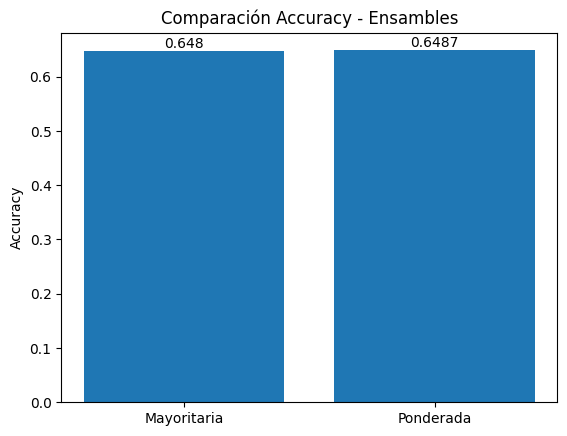

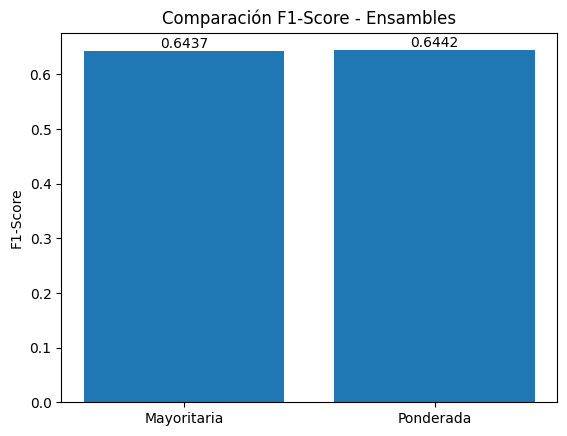

In [ ]:
# Celda 9

import matplotlib.pyplot as plt

modelos = ["Mayoritaria", "Ponderada"]

acc_majority = accuracy_score(y_test, y_pred_final)
f1_majority = f1_score(y_test, y_pred_final)
acc_weighted = accuracy_score(y_test, y_pred_weighted)      
f1_weighted = f1_score(y_test, y_pred_weighted) 

accuracy_vals = [acc_majority, acc_weighted]
f1_vals = [f1_majority, f1_weighted]

# --- Accuracy ---
plt.figure()
bars = plt.bar(modelos, accuracy_vals)
plt.ylabel("Accuracy")
plt.title("Comparación Accuracy - Ensambles")

# Mostrar valores
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4),
             ha='center', va='bottom')

plt.show()

# --- F1 Score ---
plt.figure()
bars = plt.bar(modelos, f1_vals)
plt.ylabel("F1-Score")
plt.title("Comparación F1-Score - Ensambles")

# Mostrar valores
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4),
             ha='center', va='bottom')

plt.show()

- los Resultados muestran que tanto la Votación mayoritaria como la ponderada alcanzan valores muy simples en Acurracy y F1-Score, esto concuerda con los resultados de los modelos base presentando un comportamiento homogeneo, por lo que el esquema de ponderación no introduce mejoras significativas.

- Dado que no se observan diferencias relevantes en las métricas , se toma a la votacion mayoritaria como metodo más adecuado para a actividdad, esto por su simplicidad y menor costo computacional.

- Apesar de que la  votación mayoritaria es robusta y fácil de implementar,  no distingue entre modelos con diferente calidad. contrario a la votación ponderada que permite asignar mayor importancia a modelos más precisos, lo cual puede ser ventajoso en escenarios con alta variabilidad entre modelos; sin embargo, en este caso su beneficio es limitado debido a la similitud en el desempeño de los clasificadores utilizados.